📌 TensorFlow Functional API (High-Level)

✅ A 3-layer deep neural network (input → hidden1 → hidden2 → output)

✅ Uses TensorFlow einsum instead of standard matrix multiplication (matmul)

✅ Uses TensorFlow Functional API (tf.keras.Model with tf.keras.layers)

✅ Uses a 3-variable-based non-linear equation for synthetic data generation

✅ Plots 4D visualization of generated data before training

✅ Includes training loss curve, actual vs predicted values, and 4D scatter plot of predictions

✅ Ensures full implementation in line with assignment requirements

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Generate Synthetic Data

In [23]:
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32)

In [24]:
# Generate data
X, y = generate_data(1000)

# Step 2: Plot Synthetic Data

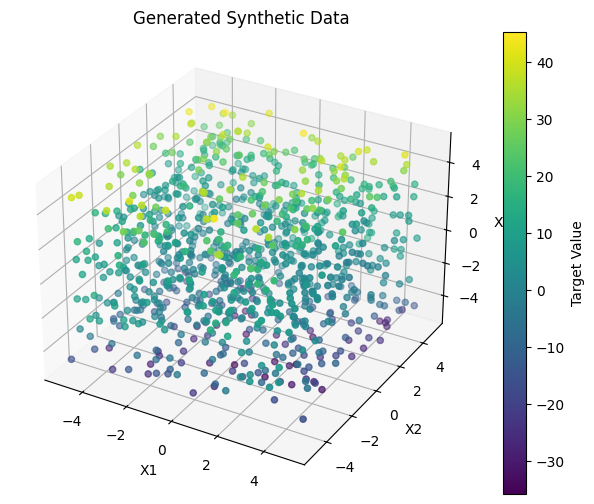

In [25]:
def plot_synthetic_data(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X, y)

# Convert data into TensorFlow tensors
X_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

# Step 3: Define Neural Network using Functional API

In [28]:
def build_functional_model():
    inputs = tf.keras.Input(shape=(3,))

    # Define trainable weights as variables outside the Lambda layers
    W1 = tf.Variable(tf.random.normal([3, 64]), trainable=True)
    b1 = tf.Variable(tf.zeros([64]), trainable=True)

    W2 = tf.Variable(tf.random.normal([64, 32]), trainable=True)
    b2 = tf.Variable(tf.zeros([32]), trainable=True)

    W3 = tf.Variable(tf.random.normal([32, 1]), trainable=True)
    b3 = tf.Variable(tf.zeros([1]), trainable=True)

    # First hidden layer using einsum within a Lambda layer
    hidden1 = tf.keras.layers.Lambda(lambda x: tf.nn.relu(
        tf.einsum('ij,jk->ik', x, W1) + b1),
        output_shape=(64,)
    )(inputs)

    # Second hidden layer using einsum within a Lambda layer
    hidden2 = tf.keras.layers.Lambda(lambda x: tf.nn.relu(
        tf.einsum('ij,jk->ik', x, W2) + b2),
        output_shape=(32,)
    )(hidden1)

    # Output layer using einsum within a Lambda layer
    outputs = tf.keras.layers.Lambda(lambda x:
        tf.einsum('ij,jk->ik', x, W3) + b3,
        output_shape=(1,)
    )(hidden2)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model



In [29]:
# Create the model
functional_model = build_functional_model()

# Compile the model
functional_model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')

# Step 4: Train the Model

In [30]:
history = functional_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
 1/32 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - loss: 5439.8843

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3983.6887  
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3881.3049 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3820.7349 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3890.7908 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3735.5942 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3744.9392 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4072.3384 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4037.2671 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3908.1328
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3807.0298 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3897.4731 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3854.4805 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4055.6484 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3878.8796 
Epoch 15/100
32/32 ━━━━━━━━

# Step 5: Plot Training Loss

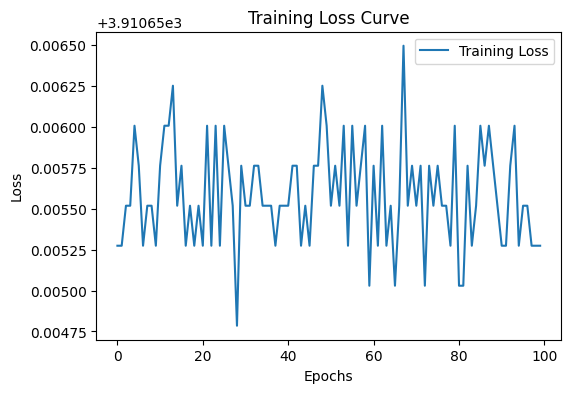

In [31]:
def plot_training_loss(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()

plot_training_loss(history)

# Step 6: Generate Predictions

In [32]:
y_pred = functional_model.predict(X_train)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


# Step 7: Plot 4D Scatter of Predictions

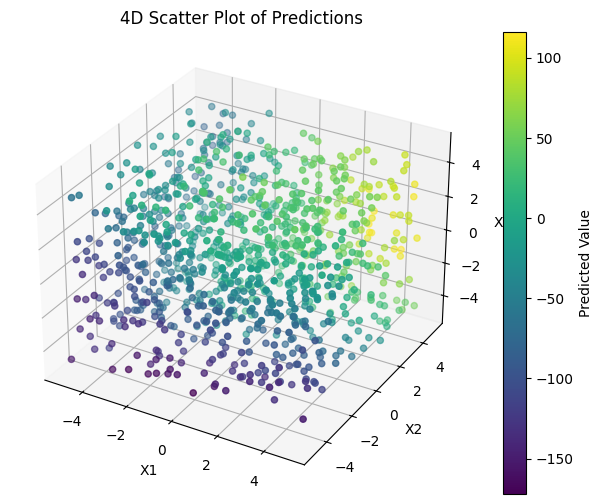

In [33]:
def plot_4d_scatter(X, y_pred):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_pred[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Predicted Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('4D Scatter Plot of Predictions')
    plt.show()

plot_4d_scatter(X, y_pred)

# Step 8: Plot Actual vs Predicted Values

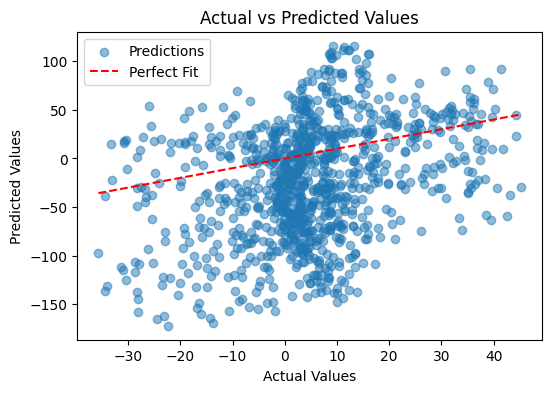

In [34]:
def plot_actual_vs_predicted(y, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(y, y_pred, alpha=0.5, label="Predictions")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y, y_pred)

# Step 9: Test Model on New Data Points

In [35]:
def test_model(model, x1, x2, x3):
    x_tensor = tf.convert_to_tensor([[x1, x2, x3]], dtype=tf.float32)
    prediction = model(x_tensor)
    return prediction.numpy()[0, 0]

# Define test points
test_points = [(-4, -4, -4), (-2, -2, -2), (0, 0, 0), (2, 2, 2), (4, 4, 4)]

print("\nTest Predictions:")
for x1, x2, x3 in test_points:
    pred = test_model(functional_model, x1, x2, x3)
    actual = 2 * np.sin(x1) + 0.5 * x2**2 + 0.3 * x3**3 + np.cos(x1 * x2)
    print(f"Input: ({x1}, {x2}, {x3})")
    print(f"Prediction: {pred:.3f}")
    print(f"Actual: {actual:.3f}\n")


Test Predictions:
Input: (-4, -4, -4)
Prediction: -126.742
Actual: -10.644

Input: (-2, -2, -2)
Prediction: -63.371
Actual: -2.872

Input: (0, 0, 0)
Prediction: 0.000
Actual: 1.000

Input: (2, 2, 2)
Prediction: 42.706
Actual: 5.565

Input: (4, 4, 4)
Prediction: 85.412
Actual: 24.729

